# UnscentedKalmanFilter — Radar Tracking Example

An object moves in a straight line with constant velocity, but the **radar measures range and bearing** (polar coordinates) — a nonlinear observation model.

Comparison:
- **EKF** — linearizes the polar model via analytical Jacobian
- **UKF** — sigma points, no Jacobians needed


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from kalman.filters import KalmanFilter
from kalman.extended import ExtendedKalmanFilter
from kalman.unscented import UnscentedKalmanFilter
from kalman.gaussian import GaussianState

torch.manual_seed(0)
np.random.seed(0)


## 1. Data Generation

Linear motion, but observations in polar coordinates: $(r, \theta) = (\sqrt{x^2+y^2},\; \arctan(y/x))$.

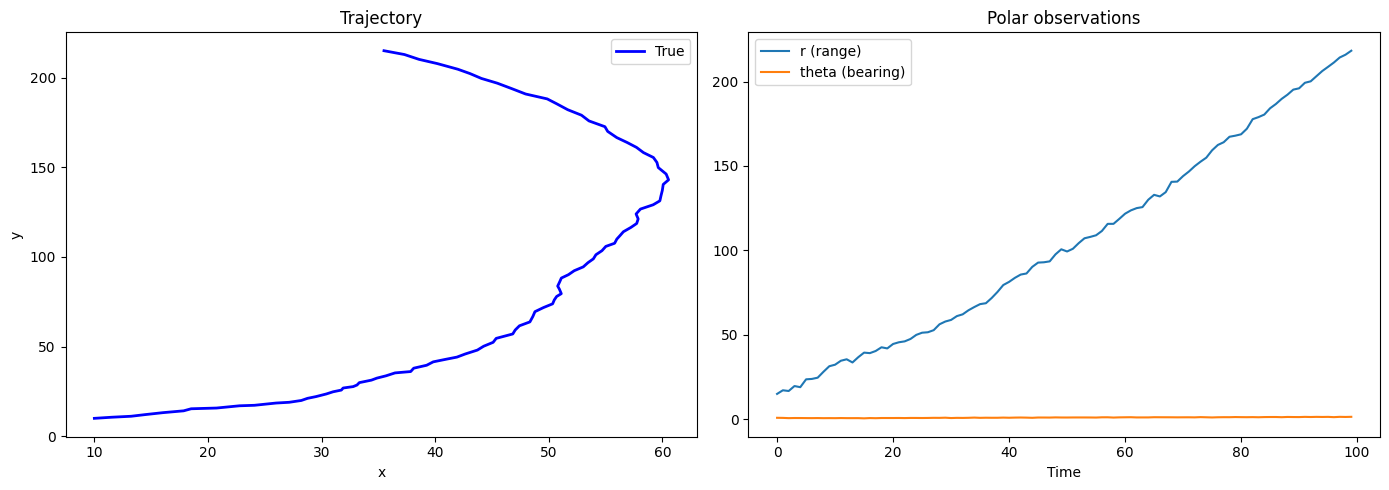

In [2]:
dt = 0.5
T = 100

# Linear dynamics: x_{t+1} = F @ x_t + w
F_np = np.array([[1, 0, dt, 0],
                 [0, 1, 0, dt],
                 [0, 0, 1, 0],
                 [0, 0, 0, 1]])

q_std = 0.3
r_range_std = 1.0  # range noise std
r_angle_std = 0.05  # bearing noise std (rad)

# True trajectory
true_states = np.zeros((T, 4))
true_states[0] = [10.0, 10.0, 2.0, 1.0]
for t in range(1, T):
    true_states[t] = F_np @ true_states[t-1] + np.random.randn(4) * q_std

# Polar observations
def cart2polar(xy):
    r = np.sqrt(xy[0]**2 + xy[1]**2)
    theta = np.arctan2(xy[1], xy[0])
    return np.array([r, theta])

obs_polar = np.zeros((T, 2))
for t in range(T):
    obs_polar[t] = cart2polar(true_states[t, :2]) + np.array([r_range_std, r_angle_std]) * np.random.randn(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(true_states[:,0], true_states[:,1], 'b-', lw=2, label='True')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].legend(); axes[0].set_title('Trajectory')
axes[1].plot(obs_polar[:,0], label='r (range)'); axes[1].plot(obs_polar[:,1], label='theta (bearing)')
axes[1].set_xlabel('Time'); axes[1].legend(); axes[1].set_title('Polar observations')
plt.tight_layout(); plt.show()


## 2. EKF with analytical Jacobian

In [3]:
F_t = torch.tensor(F_np, dtype=torch.float64)
Q_t = torch.eye(4, dtype=torch.float64) * q_std**2
R_t = torch.diag(torch.tensor([r_range_std**2, r_angle_std**2], dtype=torch.float64))

def f_linear(x):
    return (F_t @ x.unsqueeze(-1)).squeeze(-1)

def h_polar(x):
    px, py = x[..., 0], x[..., 1]
    r = torch.sqrt(px**2 + py**2)
    theta = torch.atan2(py, px)
    return torch.stack([r, theta], dim=-1)

def F_jac(x):
    return F_t.expand(*x.shape[:-1], 4, 4)

def H_jac(x):
    px, py = x[..., 0], x[..., 1]
    r2 = px**2 + py**2
    r = torch.sqrt(r2)
    J = torch.zeros(*x.shape[:-1], 2, 4, dtype=x.dtype)
    J[..., 0, 0] = px / r
    J[..., 0, 1] = py / r
    J[..., 1, 0] = -py / r2
    J[..., 1, 1] = px / r2
    return J

ekf = ExtendedKalmanFilter(4, 2, f_linear, h_polar,
    F_jacobian=F_jac, H_jacobian=H_jac, Q=Q_t, R=R_t, eps=1e-6)

state = GaussianState(torch.tensor([10., 10., 0., 0.], dtype=torch.float64),
                       torch.eye(4, dtype=torch.float64) * 100)
ekf_means = []
for t in range(T):
    state = ekf.predict(state)
    state = ekf.update(state, torch.tensor(obs_polar[t], dtype=torch.float64))
    ekf_means.append(state.mean.detach().numpy())
ekf_means = np.array(ekf_means)
print(f"EKF RMSE: {np.sqrt(np.mean((ekf_means[:,:2] - true_states[:,:2])**2)):.3f}")


EKF RMSE: 2.570


## 3. UKF — no Jacobians required

In [4]:
ukf = UnscentedKalmanFilter(4, 2, f_linear, h_polar,
    alpha=1e-3, beta=2.0, kappa=0.0, Q=Q_t, R=R_t)

state = GaussianState(torch.tensor([10., 10., 0., 0.], dtype=torch.float64),
                       torch.eye(4, dtype=torch.float64) * 100)
ukf_means = []
for t in range(T):
    state = ukf.predict(state)
    state = ukf.update(state, torch.tensor(obs_polar[t], dtype=torch.float64))
    ukf_means.append(state.mean.detach().numpy())
ukf_means = np.array(ukf_means)
print(f"UKF RMSE: {np.sqrt(np.mean((ukf_means[:,:2] - true_states[:,:2])**2)):.3f}")


UKF RMSE: 2.574


## 4. Comparison

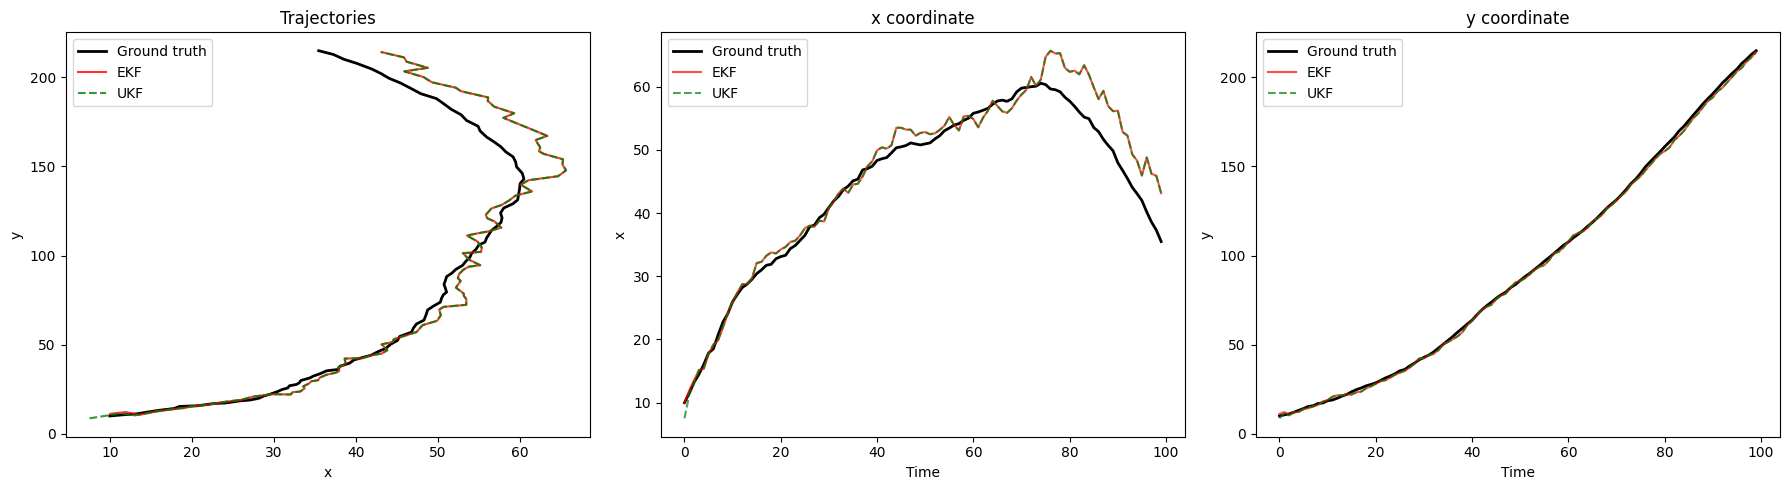

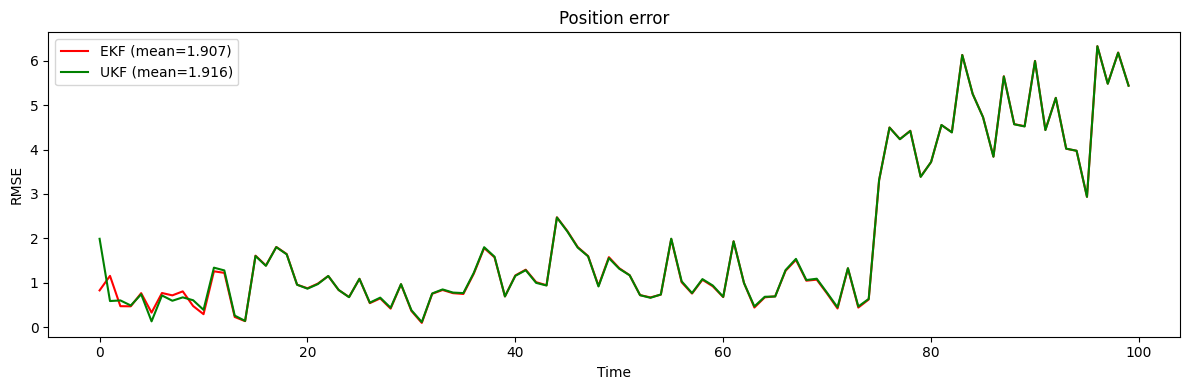

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(true_states[:,0], true_states[:,1], 'k-', lw=2, label='Ground truth')
ax.plot(ekf_means[:,0], ekf_means[:,1], 'r-', alpha=0.8, label='EKF')
ax.plot(ukf_means[:,0], ukf_means[:,1], 'g--', alpha=0.8, label='UKF')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(); ax.set_title('Trajectories')

for i, (label, ylabel) in enumerate([('x', 'x'), ('y', 'y')]):
    ax = axes[i+1]
    ax.plot(true_states[:, i], 'k-', lw=2, label='Ground truth')
    ax.plot(ekf_means[:, i], 'r-', alpha=0.7, label='EKF')
    ax.plot(ukf_means[:, i], 'g--', alpha=0.7, label='UKF')
    ax.set_xlabel('Time'); ax.set_ylabel(ylabel); ax.legend()
    ax.set_title(f'{ylabel} coordinate')

plt.tight_layout(); plt.show()

# Error comparison
ekf_err = np.sqrt(np.mean((ekf_means[:,:2] - true_states[:,:2])**2, axis=1))
ukf_err = np.sqrt(np.mean((ukf_means[:,:2] - true_states[:,:2])**2, axis=1))
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ekf_err, 'r-', label=f'EKF (mean={ekf_err.mean():.3f})')
ax.plot(ukf_err, 'g-', label=f'UKF (mean={ukf_err.mean():.3f})')
ax.set_xlabel('Time'); ax.set_ylabel('RMSE'); ax.legend()
ax.set_title('Position error'); plt.tight_layout(); plt.show()
